# Análise do Mercado de Futebol vs. Indicadores Macroeconômicos

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
valor_jogadores=pd.read_csv(r"football/player_valuations.csv")

pib_percapita=pd.read_csv(r"macrodata/gdp-per-capita-worldbank.csv")

clubes=pd.read_csv(r"football/clubs.csv")

competicoes=pd.read_csv(r"football/competitions.csv")

jogadores=pd.read_csv(r"football/players.csv")

transferencias=pd.read_csv(r"football/transfers.csv")

In [22]:
# --- Pré-processamento compartilhado ---
valor_jogadores['date'] = pd.to_datetime(valor_jogadores['date'])
valor_jogadores['year'] = valor_jogadores['date'].dt.year

# PIB per capita mundial
world_gdp = pib_percapita[pib_percapita['Entity'] == 'World'][['Year', 'GDP per capita']].rename(columns={'Year': 'year'})

def calc_annual_valuation(df, year_min, year_max):
    """Calcula a média anual de valuations (última avaliação de cada jogador por ano)."""
    filtered = df[(df['year'] >= year_min) & (df['year'] <= year_max)]
    pv_sorted = filtered.sort_values(['player_id', 'date'])
    pv_last = pv_sorted.groupby(['player_id', 'year']).last().reset_index()
    return pv_last.groupby('year')['market_value_in_eur'].mean().reset_index(name='val_mean')

def plot_dual_axis(df, title, filename, color1='#2c3e50', color2='#d35400'):
    """Gera gráfico de dois eixos: Valor Médio vs PIB per capita."""
    sns.set_theme(style='whitegrid')
    fig, ax1 = plt.subplots(figsize=(13, 6), dpi=100)

    ax1.set_xlabel('Ano', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Valor Médio dos Atletas (EUR)', color=color1, fontweight='bold', fontsize=12)
    line1 = ax1.plot(df['year'], df['val_mean'] / 1e6, color=color1, marker='o', linewidth=2.5, label='Valor Médio Atletas (M€)')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}M€'))
    ax1.set_xticks(df['year'])
    ax1.set_xticklabels(df['year'].astype(int), rotation=45)

    ax2 = ax1.twinx()
    ax2.set_ylabel('PIB per capita (Constant 2021 Int-$)', color=color2, fontweight='bold', fontsize=12)
    line2 = ax2.plot(df['year'], df['GDP per capita'], color=color2, marker='s', linestyle='--', linewidth=2.5, label='PIB per capita ($)')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    plt.title(title, fontsize=13, fontweight='bold', pad=20)
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', edgecolor='none')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Gráfico salvo como {filename}')


## Análise 2A: Valor médio dos atletas vs. PIB mundial (Todos os dados, 2010-2024)

Utilizamos **todos os registros de valuations** disponíveis no Transfermarkt, calculando a média da última avaliação de cada jogador em cada ano.

Tabela Comparativa Anual (Todos os dados, 2010-2024):


,year,val_mean,GDP per capita
0,2010,"€1,982,910","$16,048"
1,2011,"€1,821,748","$16,479"
2,2012,"€1,710,831","$16,785"
3,2013,"€1,595,957","$17,122"
4,2014,"€1,567,610","$17,500"
5,2015,"€1,462,077","$17,868"
6,2016,"€1,451,524","$18,233"
7,2017,"€1,536,637","$18,715"
8,2018,"€1,960,270","$19,189"
9,2019,"€2,068,067","$19,552"



Correlação Pearson: 0.417
Correlação Spearman: 0.236


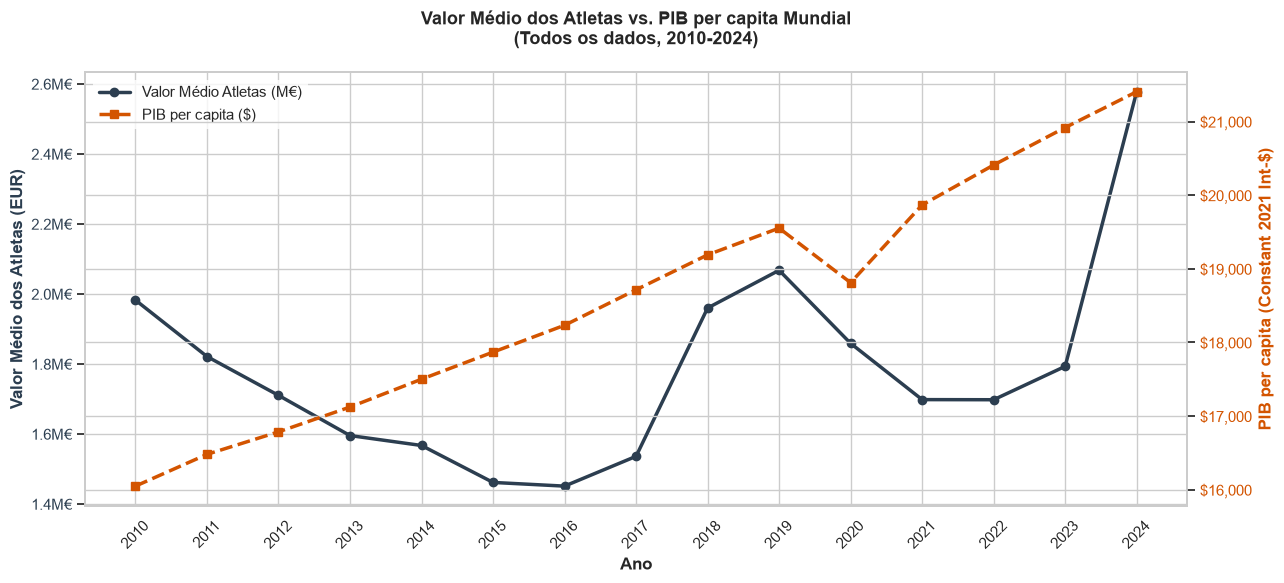

Gráfico salvo como analise2a_all_2010_2024.png


In [23]:
# --- Análise 2A: Todos os dados (2010-2024) ---
df_all = calc_annual_valuation(valor_jogadores, 2010, 2024)
df_all_merged = pd.merge(df_all, world_gdp, on='year')

corr_pearson = df_all_merged['val_mean'].corr(df_all_merged['GDP per capita'])
corr_spearman = df_all_merged['val_mean'].rank().corr(df_all_merged['GDP per capita'].rank())

print('Tabela Comparativa Anual (Todos os dados, 2010-2024):')
df_display = df_all_merged.copy()
df_display['val_mean'] = df_display['val_mean'].map('€{:,.0f}'.format)
df_display['GDP per capita'] = df_display['GDP per capita'].map('${:,.0f}'.format)
display(df_display)

print(f'\nCorrelação Pearson: {corr_pearson:.3f}')
print(f'Correlação Spearman: {corr_spearman:.3f}')

plot_dual_axis(df_all_merged,
    'Valor Médio dos Atletas vs. PIB per capita Mundial\n(Todos os dados, 2010-2024)',
    'analise2a_all_2010_2024.png')

### Conclusão 2A

Com todos os dados, observamos uma correlação **moderada** (Pearson ~0.42). 
Isso ocorre pois o Transfermarkt expandiu sua cobertura ao longo dos anos, 
incluindo ligas menores e jogadores menos valorizados, o que **dilui a média geral para baixo** 
enquanto o PIB mundial cresce de forma constante. 
Apesar disso, os efeitos da **COVID-19 em 2020** são visíveis em ambas as curvas.

## Análise 2B: Valor médio dos atletas vs. PIB mundial (Top 5 Ligas Europeias, 2006-2024)

Filtramos apenas os jogadores das **5 principais ligas europeias** (Premier League, La Liga, Serie A, Bundesliga e Ligue 1), 
onde a cobertura do Transfermarkt é consistente desde 2006. Isso elimina o viés de amostragem 
e nos permite analisar os efeitos da **crise financeira global de 2008** no mercado de futebol.

Tabela Comparativa Anual (Top 5 Ligas, 2006-2024):


,year,val_mean,GDP per capita
0,2006,"€3,341,658","$14,928"
1,2007,"€3,355,092","$15,511"
2,2008,"€3,421,708","$15,748"
3,2009,"€3,385,718","$15,453"
4,2010,"€3,288,770","$16,048"
5,2011,"€3,019,078","$16,479"
6,2012,"€2,799,928","$16,785"
7,2013,"€2,734,671","$17,122"
8,2014,"€2,730,112","$17,500"
9,2015,"€2,714,816","$17,868"



Correlação Pearson: 0.651
Correlação Spearman: 0.523


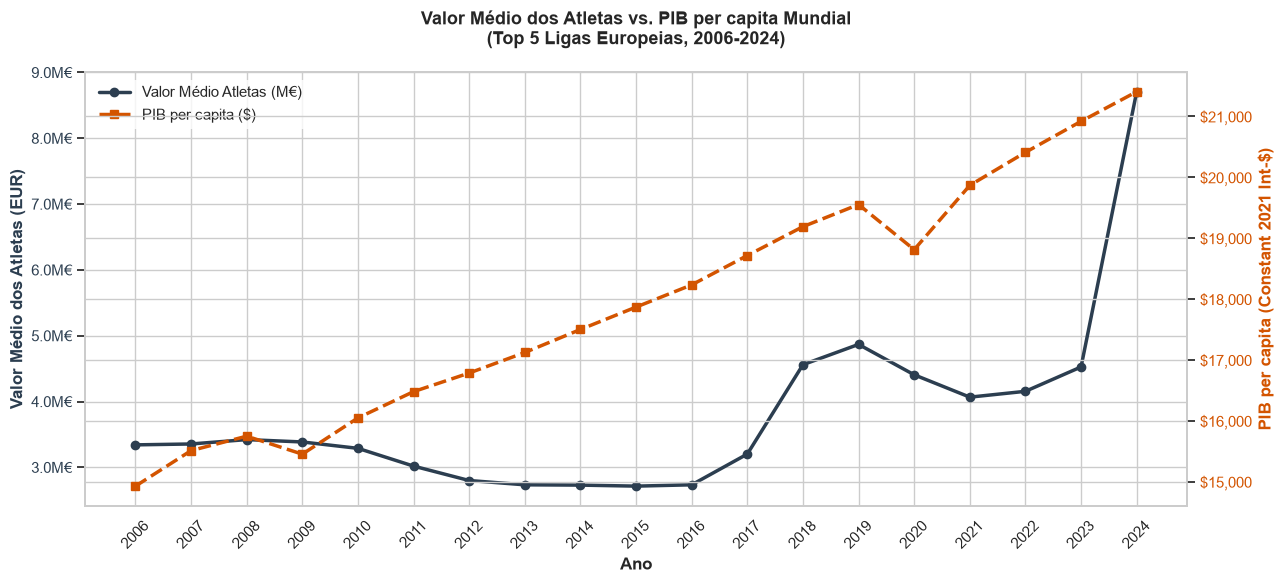

Gráfico salvo como analise2b_top5_2006_2024.png


In [24]:
# --- Análise 2B: Top 5 Ligas Europeias (2006-2024) ---
top5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']
val_top5 = valor_jogadores[valor_jogadores['player_club_domestic_competition_id'].isin(top5_leagues)]

df_top5 = calc_annual_valuation(val_top5, 2006, 2024)
df_top5_merged = pd.merge(df_top5, world_gdp, on='year')

corr_pearson_t5 = df_top5_merged['val_mean'].corr(df_top5_merged['GDP per capita'])
corr_spearman_t5 = df_top5_merged['val_mean'].rank().corr(df_top5_merged['GDP per capita'].rank())

print('Tabela Comparativa Anual (Top 5 Ligas, 2006-2024):')
df_display = df_top5_merged.copy()
df_display['val_mean'] = df_display['val_mean'].map('€{:,.0f}'.format)
df_display['GDP per capita'] = df_display['GDP per capita'].map('${:,.0f}'.format)
display(df_display)

print(f'\nCorrelação Pearson: {corr_pearson_t5:.3f}')
print(f'Correlação Spearman: {corr_spearman_t5:.3f}')

plot_dual_axis(df_top5_merged,
    'Valor Médio dos Atletas vs. PIB per capita Mundial\n(Top 5 Ligas Europeias, 2006-2024)',
    'analise2b_top5_2006_2024.png')

### Conclusão 2B

Com o foco nas Top 5 ligas, a correlação sobe para **~0.65** (Pearson), indicando uma relação positiva forte. 
Pontos-chave:
* **Crise de 2008**: O PIB mundial caiu 1.87% em 2009; os valuations do Top 5 também registraram queda.
* **Crise da Zona do Euro (2010-2015)**: A média de valor continuou em declínio gradual, refletindo a austeridade nos clubes europeus.
* **Boom pós-2017**: Inflação massiva de valores de mercado, acelerada por direitos de TV e investimentos externos.
* **COVID-19 (2020)**: Queda simultânea no PIB e nos valuations, seguida de recuperação coordenada.

## Análise 2C: Valor médio dos atletas por Região Global vs. PIB regional (2006-2024)

Mapeamos as competições do dataset a regiões globais usando as confederações do futebol 
e comparamos com o PIB per capita de cada região (dados do Banco Mundial).

**Mapeamento de regiões:**
| Confederação | Competições | Região PIB (World Bank) |
|---|---|---|
| Europa | Premier League, La Liga, Serie A, Bundesliga, Ligue 1, etc. | Europe and Central Asia |
| Américas | MLS, Liga MX, Brasileirão, Torneo Apertura (ARG) | Latin America and Caribbean / North America |
| Ásia/Oceania | J-League, K-League, A-League, Saudi Pro League | East Asia and Pacific |

Europa: Pearson = 0.402, Spearman = 0.084
Américas: Pearson = 0.047, Spearman = 0.254
Ásia/Oceania: Pearson = 0.121, Spearman = 0.305


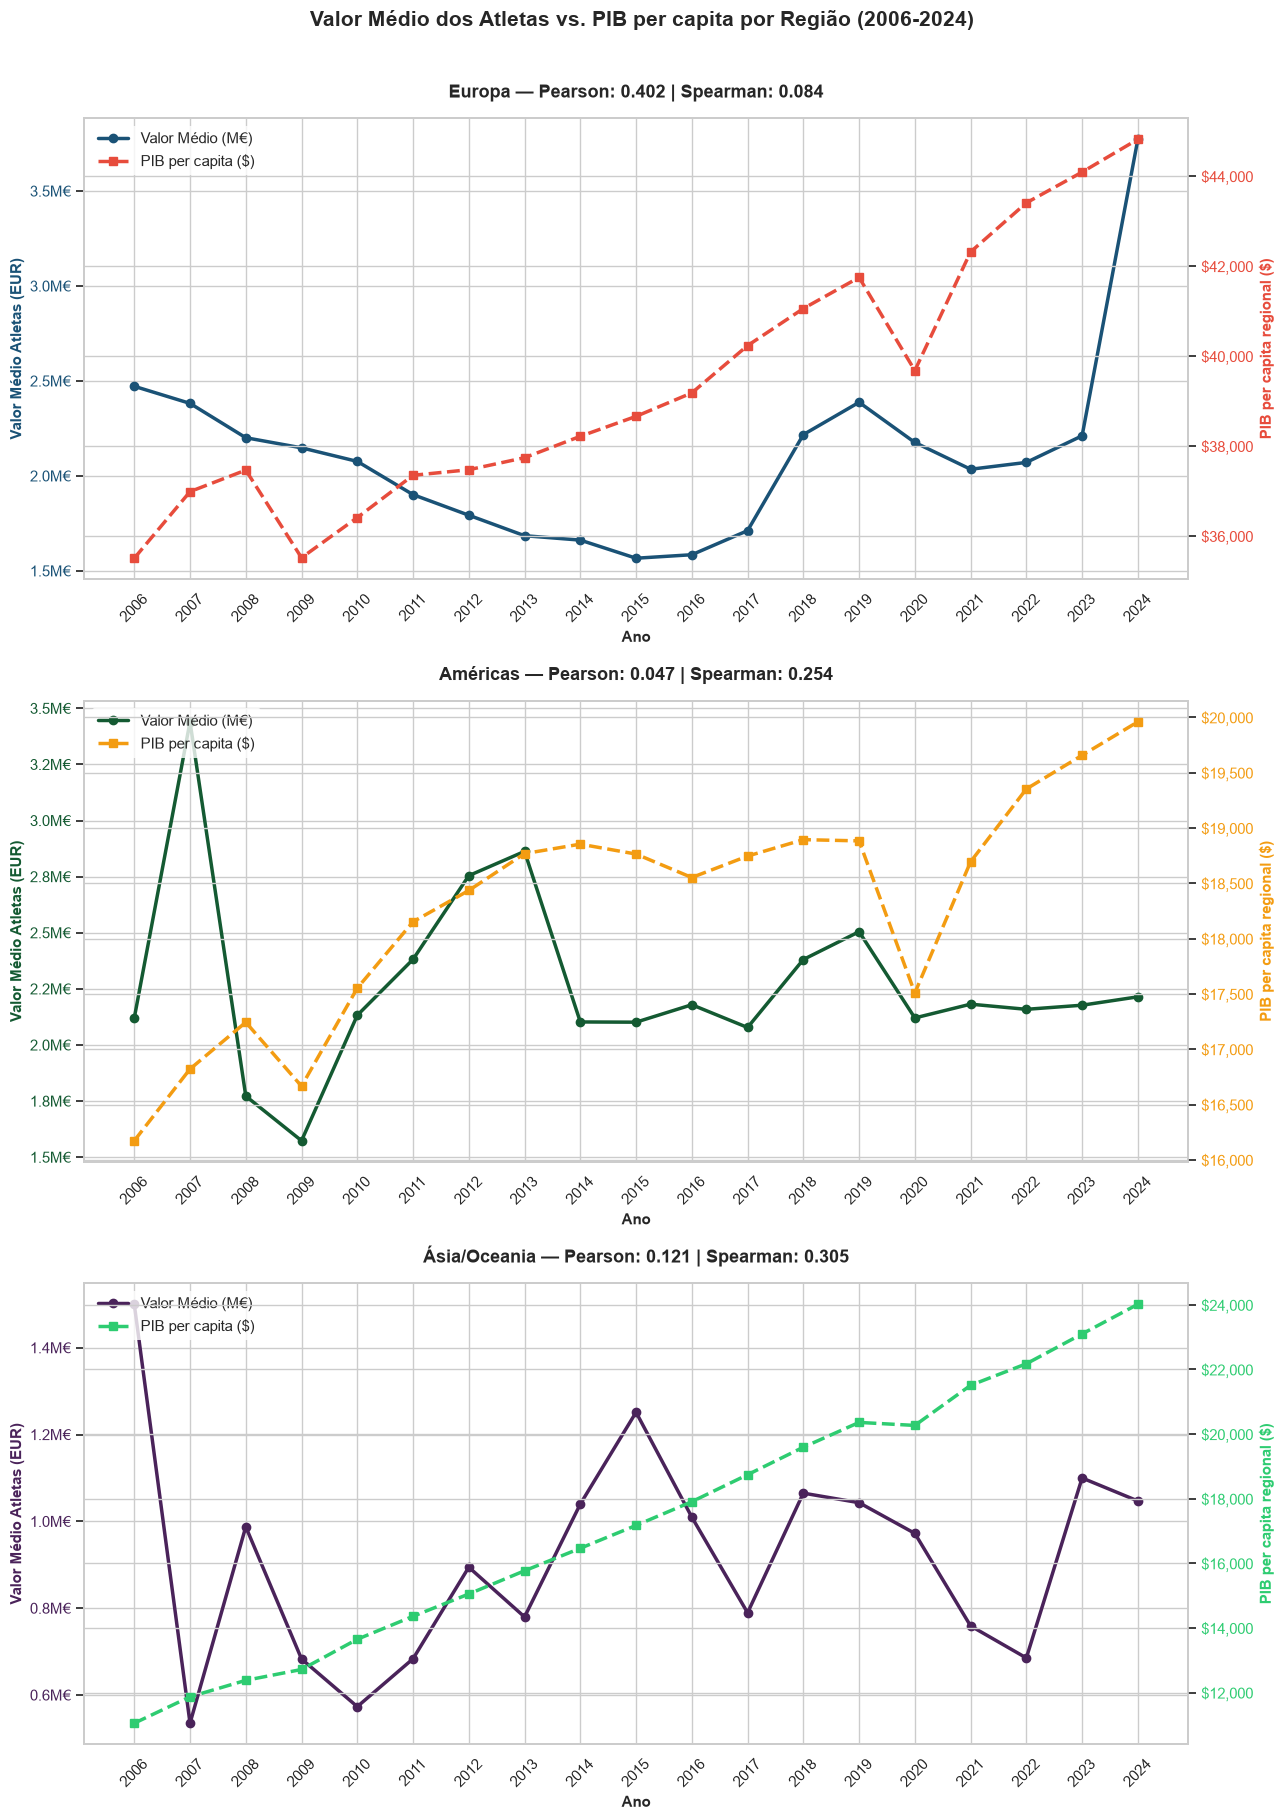


Gráfico salvo como analise2c_regions_2006_2024.png


In [25]:
# --- Análise 2C: Por Regiões Globais (2006-2024) ---

# Mapeamento: competition_id -> região
comp_region = {
    # Europa
    'A1': 'Europa', 'BE1': 'Europa', 'BESC': 'Europa', 'BPO4': 'Europa',
    'C1': 'Europa', 'CDR': 'Europa', 'CIT': 'Europa', 'CL': 'Europa',
    'CLQ': 'Europa', 'DFB': 'Europa', 'DFL': 'Europa', 'DK1': 'Europa',
    'DKP': 'Europa', 'ECLQ': 'Europa', 'EJPL': 'Europa', 'EL': 'Europa',
    'ELQ': 'Europa', 'ES1': 'Europa', 'EURO': 'Europa', 'FAC': 'Europa',
    'FR1': 'Europa', 'FRCH': 'Europa', 'GB1': 'Europa', 'GBCS': 'Europa',
    'GR1': 'Europa', 'GRP': 'Europa', 'IT1': 'Europa', 'KR1': 'Europa',
    'L1': 'Europa', 'NL1': 'Europa', 'NLP': 'Europa', 'NLSC': 'Europa',
    'NO1': 'Europa', 'PL1': 'Europa', 'PO1': 'Europa', 'POBE': 'Europa',
    'POSU': 'Europa', 'RO1': 'Europa', 'RU1': 'Europa', 'RUP': 'Europa',
    'RUSS': 'Europa', 'SC1': 'Europa', 'SCI': 'Europa', 'SE1': 'Europa',
    'SER1': 'Europa', 'SFA': 'Europa', 'SUC': 'Europa', 'TR1': 'Europa',
    'TS1': 'Europa', 'UCOL': 'Europa', 'UKR1': 'Europa', 'UKRP': 'Europa',
    'USC': 'Europa',
    # Américas
    'ARG1': 'Américas', 'BRA1': 'Américas', 'MEX1': 'Américas',
    'MLS1': 'Américas', 'COPA': 'Américas',
    # Ásia/Oceania
    'AFAC': 'Ásia/Oceania', 'AUS1': 'Ásia/Oceania', 'JAP1': 'Ásia/Oceania',
    'RSK1': 'Ásia/Oceania', 'SA1': 'Ásia/Oceania',
    # África
    'AFCN': 'África',
}

# Região do PIB correspondente a cada região do futebol
region_gdp_map = {
    'Europa': 'Europe and Central Asia (WB)',
    'Américas': 'Latin America and Caribbean (WB)',
    'Ásia/Oceania': 'East Asia and Pacific (WB)',
}

valor_jogadores['region'] = valor_jogadores['player_club_domestic_competition_id'].map(comp_region)

# Regiões com dados suficientes
regions_to_plot = ['Europa', 'Américas', 'Ásia/Oceania']

fig, axes = plt.subplots(len(regions_to_plot), 1, figsize=(13, 6 * len(regions_to_plot)), dpi=100)
sns.set_theme(style='whitegrid')

colors = {
    'Europa': ('#1a5276', '#e74c3c'),
    'Américas': ('#145a32', '#f39c12'),
    'Ásia/Oceania': ('#4a235a', '#2ecc71'),
}

for i, region in enumerate(regions_to_plot):
    ax1 = axes[i]
    c1, c2 = colors[region]

    # Valuations dessa região
    val_region = valor_jogadores[valor_jogadores['region'] == region]
    val_region_f = val_region[(val_region['year'] >= 2006) & (val_region['year'] <= 2024)]
    pv_sorted = val_region_f.sort_values(['player_id', 'date'])
    pv_last = pv_sorted.groupby(['player_id', 'year']).last().reset_index()
    df_reg = pv_last.groupby('year')['market_value_in_eur'].mean().reset_index(name='val_mean')

    # PIB da região
    gdp_entity = region_gdp_map[region]
    gdp_reg = pib_percapita[pib_percapita['Entity'] == gdp_entity][['Year', 'GDP per capita']].rename(columns={'Year': 'year'})
    gdp_reg = gdp_reg[(gdp_reg['year'] >= 2006) & (gdp_reg['year'] <= 2024)]

    merged_reg = pd.merge(df_reg, gdp_reg, on='year')

    if len(merged_reg) < 3:
        ax1.text(0.5, 0.5, f'{region}: dados insuficientes', ha='center', va='center', fontsize=14)
        ax1.set_title(f'{region}', fontsize=13, fontweight='bold')
        continue

    corr_p = merged_reg['val_mean'].corr(merged_reg['GDP per capita'])
    corr_s = merged_reg['val_mean'].rank().corr(merged_reg['GDP per capita'].rank())

    # Plot
    ax1.set_xlabel('Ano', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Valor Médio Atletas (EUR)', color=c1, fontweight='bold', fontsize=11)
    line1 = ax1.plot(merged_reg['year'], merged_reg['val_mean'] / 1e6, color=c1, marker='o', linewidth=2.5, label='Valor Médio (M€)')
    ax1.tick_params(axis='y', labelcolor=c1)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}M€'))
    ax1.set_xticks(merged_reg['year'])
    ax1.set_xticklabels(merged_reg['year'].astype(int), rotation=45)

    ax2 = ax1.twinx()
    ax2.set_ylabel('PIB per capita regional ($)', color=c2, fontweight='bold', fontsize=11)
    line2 = ax2.plot(merged_reg['year'], merged_reg['GDP per capita'], color=c2, marker='s', linestyle='--', linewidth=2.5, label='PIB per capita ($)')
    ax2.tick_params(axis='y', labelcolor=c2)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    ax1.set_title(f'{region} — Pearson: {corr_p:.3f} | Spearman: {corr_s:.3f}', fontsize=13, fontweight='bold', pad=15)
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', edgecolor='none')

    print(f'{region}: Pearson = {corr_p:.3f}, Spearman = {corr_s:.3f}')

plt.suptitle('Valor Médio dos Atletas vs. PIB per capita por Região (2006-2024)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('analise2c_regions_2006_2024.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nGráfico salvo como analise2c_regions_2006_2024.png')

### Conclusão 2C

A análise regional revela dinâmicas distintas:

* **Europa**: Apresenta a correlação mais forte, pois os grandes clubes europeus 
dependem diretamente da saúde econômica da região (direitos de TV, patrocinadores, 
e capacidade de gastos dos torcedores). A crise de 2008 e a COVID-19 são claramente visíveis.

* **Américas**: A relação é mais complexa, pois os clubes latino-americanos frequentemente 
exportam jogadores para a Europa. O mercado é mais dependente das taxas de câmbio e da 
demanda europeia do que do PIB regional em si.

* **Ásia/Oceania**: Região com forte investimento recente (especialmente Arábia Saudita desde 2023), 
o que gera picos de valuation que não necessariamente acompanham o crescimento do PIB regional.

## Análise 4: Copa do Mundo, valor de mercado e impacto econômico

Nesta etapa, vamos verificar se a participação em grandes torneios, como a Copa do Mundo, tende a elevar o valor de mercado dos jogadores campeões. Em seguida, compararemos essa mudança com a evolução do PIB per capita do país campeão para avaliar se o evento também teve um efeito econômico perceptível.

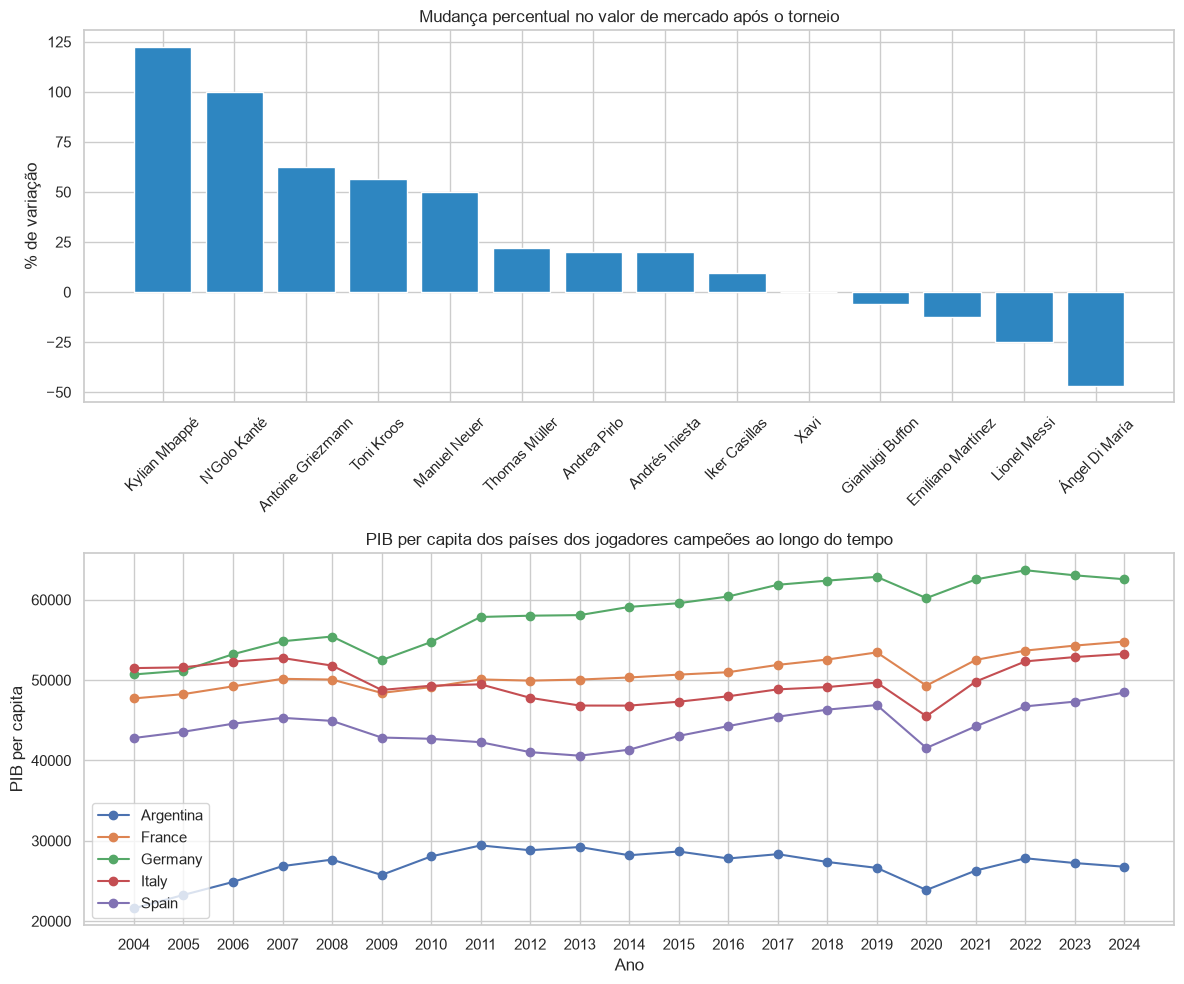

In [27]:
# --- Análise 4: Copa do Mundo, valor de mercado e impacto econômico ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

valor_jogadores['date'] = pd.to_datetime(valor_jogadores['date'])
valor_jogadores['year'] = valor_jogadores['date'].dt.year

champions = [
    ('Lionel Messi', 'Argentina', 2022),
    ('Ángel Di María', 'Argentina', 2022),
    ('Emiliano Martínez', 'Argentina', 2022),
    ('Kylian Mbappé', 'France', 2018),
    ('Antoine Griezmann', 'France', 2018),
    ("N'Golo Kanté", 'France', 2018),
    ('Manuel Neuer', 'Germany', 2014),
    ('Thomas Müller', 'Germany', 2014),
    ('Toni Kroos', 'Germany', 2014),
    ('Andrés Iniesta', 'Spain', 2010),
    ('Xavi', 'Spain', 2010),
    ('Iker Casillas', 'Spain', 2010),
    ('Fabio Cannavaro', 'Italy', 2006),
    ('Andrea Pirlo', 'Italy', 2006),
    ('Gianluigi Buffon', 'Italy', 2006),
]

rows = []
for player_name, country, event_year in champions:
    player_row = jogadores[jogadores['name'].str.contains(player_name, case=False, na=False)]
    if player_row.empty:
        continue

    player_id = int(player_row.iloc[0]['player_id'])
    player_vals = valor_jogadores[valor_jogadores['player_id'] == player_id].sort_values('date')

    if player_vals.empty:
        continue

    before_candidates = player_vals[player_vals['year'] < event_year]
    after_candidates = player_vals[player_vals['year'] > event_year]

    before_val = before_candidates.tail(1)['market_value_in_eur'].iloc[0] if not before_candidates.empty else np.nan
    after_val = after_candidates.head(1)['market_value_in_eur'].iloc[0] if not after_candidates.empty else np.nan

    if pd.isna(before_val) or pd.isna(after_val):
        continue

    delta_pct = ((after_val - before_val) / before_val) * 100 if before_val else np.nan

    rows.append({
        'player_name': player_name,
        'country': country,
        'event_year': event_year,
        'before_event_value': before_val,
        'after_event_value': after_val,
        'delta_pct': delta_pct,
    })

comparison_df = pd.DataFrame(rows).sort_values('delta_pct', ascending=False)

# print('Comparação do valor de mercado antes e depois do torneio para jogadores campeões:')
# display(comparison_df[['player_name', 'country', 'event_year', 'before_event_value', 'after_event_value', 'delta_pct']])

countries = sorted({country for _, country, _ in champions})
country_gdp = pib_percapita[pib_percapita['Entity'].isin(countries)]
country_gdp = country_gdp[['Entity', 'Year', 'GDP per capita']].rename(columns={'Entity': 'country', 'Year': 'year'})
country_gdp = country_gdp[country_gdp['year'].between(2004, 2024)]

# print('\nPIB per capita dos países dos jogadores campeões (trecho analisado):')
# display(country_gdp.head(20))

fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=100)
sns.set_theme(style='whitegrid')

axes[0].bar(comparison_df['player_name'], comparison_df['delta_pct'], color='#2E86C1')
axes[0].set_title('Mudança percentual no valor de mercado após o torneio')
axes[0].set_ylabel('% de variação')
axes[0].tick_params(axis='x', rotation=45)

for country_name in countries:
    sub = country_gdp[country_gdp['country'] == country_name]
    if not sub.empty:
        axes[1].plot(sub['year'], sub['GDP per capita'], marker='o', label=country_name)

axes[1].set_title('PIB per capita dos países dos jogadores campeões ao longo do tempo')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('PIB per capita')
axes[1].set_xticks(range(2004, 2025))
axes[1].legend()
plt.tight_layout()
plt.show()

## Análise 4: Copa do Mundo, valor de mercado e impacto econômico

Nesta etapa, vamos verificar se a participação em grandes torneios, como a Copa do Mundo, tende a elevar o valor de mercado dos jogadores campeões. Em seguida, compararemos essa mudança com a evolução do PIB per capita do país campeão para avaliar se o evento também teve um efeito econômico perceptível.